
---

# PyTorch 极速入门：从零手写到专业工程化 (学习笔记)

### 核心观点
核心理念是：PyTorch 底层的 5 步法则：前向传播（Forward）、损失计算（Loss）、反向传播（Backward）、参数更新（Update）、梯度重置（Reset）
---

### 第一部分：万物基石 —— Tensor (张量)

**1. Tensor 的本质**
Tensor 是 PyTorch 中的基本数据结构，可以理解为“带超能力的 NumPy 数组”。

**2. 创建 Tensor 的三种常用模式**

* **直接数据创建**：使用 `torch.tensor(data)` 将 Python 列表转换为 Tensor。
* **指定形状创建**：在初始化模型权重时非常有用。例如 `torch.randn(shape)` 生成随机数，`torch.zeros(shape)` 生成全零张量。
* **模仿创建 (Mimic)**：创建一个与现有 Tensor 形状、设备、类型完全相同的新 Tensor，例如 `torch.randn_like(input_tensor)`。

**3. 三大关键属性 (Debug 神器)**
每个 Tensor 都有三个核心属性，Debug 时 90% 的问题都出在这里：

* **Shape (形状)**：最重要的属性，维度不匹配是报错的主要原因。
* **Device (设备)**：数据是在 CPU 还是 GPU (CUDA) 上。
* **Dtype (数据类型)**：
* **重点**：模型参数（权重、偏置）必须是 `float32`。
* **原因**：梯度下降需要进行微小的连续调整（如从 3.0 变到 3.001），整数类型无法支持这种微调。

---

### 第二部分：神经系统 —— Autograd (自动微分)

**1. 魔法开关：`requires_grad=True**`

* 默认情况下，Tensor 只是普通数据。
* 一旦设置 `requires_grad=True`，PyTorch 的 Autograd 引擎就会开始追踪在该 Tensor 上发生的所有操作。
* **用途**：告诉 PyTorch “这是一个需要学习的参数（Parameter），不是普通的输入数据（Data）”。

**2. 计算图 (Computation Graph)**

* 当你对参数进行运算（如 `y = a + b`）时，PyTorch 会在后台动态构建一个有向无环图。
* **面包屑导航 (`grad_fn`)**：每个由运算产生的新 Tensor 都会记录它是如何生成的（例如通过“加法”或“乘法”）。这为后续的反向传播提供了路径地图。

---

### 第三部分：核心动词 —— 常用操作

**1. 矩阵乘法 vs 逐元素乘法 (新手必坑)**

* **`*` (星号)**：逐元素乘法 (Element-wise)。要求形状完全一致，对应位置相乘。
* **`@` (At 符号)**：矩阵乘法。神经网络的核心操作（如线性层 `y = xW + b`）。规则是第一个矩阵的列数必须等于第二个矩阵的行数。

**2. 降维操作与 `dim` 参数**

* `sum`, `mean` 等聚合操作。
* **理解 `dim**`：`dim=0` 表示沿着行（纵向）压缩，`dim=1` 表示沿着列（横向）压缩。理解这一点对于处理 Batch 数据至关重要。

**3. 高级选择：`gather**`

* 比普通索引更灵活。可以为每一行指定不同的列索引来提取数据。这是实现复杂模型架构和特定数据提取的关键算子。

---

### 第四部分：从零手写神经网络 (手动挡)

在不使用任何高级 API 的情况下，完全用数学公式实现一个线性回归模型（`y = 2x + 1`）：

**1. 前向传播 (The Guess)**

* 初始化随机权重的 `W` 和 `B`。
* 执行预测：`y_pred = X @ W + B`。初始预测结果通常是完全错误的噪声。

**2. 计算损失 (The Scorecard)**

* 使用均值平方误差 (MSE) 来衡量预测值与真实值之间的差距。
* 损失值 (Loss) 是一个标量，它是整个计算图的终点。

**3. 反向传播 (The Blame)**

* 执行 `loss.backward()`。
* 这是 PyTorch 最强大的一行代码。它会沿着计算图反向回溯，计算 Loss 对每个参数（W 和 B）的梯度，并将结果存储在参数的 `.grad` 属性中。

**4. 梯度下降 (The Update)**

* 梯度指向 Loss 增加最快的方向，为了降低 Loss，我们需要向梯度的**反方向**更新参数。
* **公式**：`W_new = W_old - learning_rate * W.grad`。
* 注意：更新操作需要包裹在 `torch.no_grad()` 中，避免更新过程本身被记录进计算图。

**5. 重置梯度 (The Reset)**

* 执行 `w.grad.zero_()`。
* 必须在每一轮迭代后清空梯度，否则梯度会累加，导致无法正确训练。

---

### 第五部分：走向专业化 —— `torch.nn` 与工程化

手动管理参数太麻烦，PyTorch 提供了更高级的抽象。

**1. `nn.Module` (蓝图)**

* 所有自定义模型都继承自 `nn.Module`。
* **`__init__`**：定义所有的层（Layer），如 `self.linear = nn.Linear(...)`。
* **`forward`**：定义数据流向，即层与层之间如何连接。

**2. 常用层 (Lego Bricks)**

* **`nn.Linear`**：封装了 `W` 和 `B`，自动处理参数初始化和形状管理。
* **激活函数**：
* **ReLU**：负数归零，正数不变。简单有效。
* **GELU**：Transformer (如 BERT, GPT) 标配，比 ReLU 更平滑。
* **Softmax**：用于分类任务的输出层，将数值转换为概率分布（和为1）。


* **`nn.Embedding`**：将单词 ID 转换为向量（查表操作）。
* **`nn.LayerNorm`**：稳定数值范围，防止梯度爆炸/消失，深层网络必备。
* **`nn.Dropout`**：训练时随机“关闭”部分神经元，防止过拟合。注意训练模式 (`.train()`) 和评估模式 (`.eval()`) 行为不同。

**3. 优化器 `torch.optim` (建造者)**

* 不再需要手写 `W = W - lr * grad`。
* 使用 `optimizer = optim.Adam(model.parameters(), lr=0.01)`。
* 它负责管理所有的参数更新逻辑。

---

### 第六部分：通用的训练循环 (The Loop)

无论模型多复杂，PyTorch 的训练循环核心代码几乎永远是这**三行真言 (Three-line Mantra)**：

```python
# 1. 清空过往梯度
optimizer.zero_grad()

# 2. 反向传播计算新梯度
loss.backward()

# 3. 根据梯度更新参数
optimizer.step()

```

配合前向传播和 Loss 计算，这就是一个完整的 Epoch 流程。

---

### 总结与升华：从线性回归到 LLM

视频最后展示了一个惊人的事实：
我们刚才手写的简单线性模型，与拥有 80 亿参数的 Llama 3 大模型，在**训练架构上是完全一致的**。

* **结构一致**：Transformer 内部的前馈网络 (FFN) 本质上就是 `Linear -> GELU -> Linear` 的组合。
* **流程一致**：无论参数是 2 个还是 80 亿个，训练的核心依旧是：计算 Loss -> `loss.backward()` -> `optimizer.step()`。
* **区别**：仅仅是矩阵的**规模 (Scale)** 不同。

**结论**：你并没有在这个视频里学到一个简化的“玩具”模型，你学到的是驱动当今最强 AI 模型的真实引擎。去掉了对“魔法”的迷信，留下的就是纯粹的工程学。

In [57]:
import torch

# 张量


直接数据创建

In [58]:
data = [[1,2,3],[4,5,6]]

my_tensor = torch.tensor(data)

print(my_tensor)

tensor([[1, 2, 3],
        [4, 5, 6]])


指定形状创建

In [59]:
shape = (2,3)

ones = torch.ones(shape)
zeros = torch.zeros(shape)
random = torch.randn(shape)

print("Ones:\n", ones)
print("Zeros:\n", zeros)
print("Random:\n", random)

Ones:
 tensor([[1., 1., 1.],
        [1., 1., 1.]])
Zeros:
 tensor([[0., 0., 0.],
        [0., 0., 0.]])
Random:
 tensor([[ 0.1828, -0.1824,  0.9879],
        [-1.9276,  0.4780,  0.5006]])


模仿创建（按已有张量创建）


### 数据类型（dtype）

### 每个张量都有一个**数据类型**。主要关注的数据类型：
### - **浮点数**（`torch.float32`）：用于模型参数和需要梯度计算的数据
### - **整数**（`torch.int`、`torch.int64`）：用于标签、索引、计数等离散信息

### 1. **模型参数**：必须是 float 类型（通常 float32），因为需要连续优化
### 2. **输入数据**：如果默认推断为 int，但需要梯度，必须转为 float
### 3. **标签/索引**：保持 int 类型，不需要梯度

### 可以在创建张量时通过 `dtype` 参数明确指定数据类型：

In [60]:
template = torch.tensor([[1, 2], [3, 4]])
# rand_like 是一个和 template 张量形状一致的张量，但其中的元素是从标准正态分布（均值为0，方差为1）随机采样的浮点数
rand_like = torch.randn_like(template, dtype=torch.float)

print("rand_like:")
print(rand_like)


rand_like:
tensor([[-1.3522, -0.4223],
        [ 0.1983,  1.7157]])


In [61]:
tensor = torch.randn(2,3)

print(f"Shape:{tensor.shape}")
print(f"Datatype:{tensor.dtype}")
print(f"Device:{tensor.device}")


Shape:torch.Size([2, 3])
Datatype:torch.float32
Device:cpu


In [62]:
matr_3d = torch.tensor([[[1, 2, 3, 4], [-2, 5, 6, 9]], [[5, 6, 7, 2], [8, 9, 10, 4]], [[-3, 2, 2, 1], [4, 6, 5, 9]]])
print(matr_3d)
print(matr_3d.shape)

tensor([[[ 1,  2,  3,  4],
         [-2,  5,  6,  9]],

        [[ 5,  6,  7,  2],
         [ 8,  9, 10,  4]],

        [[-3,  2,  2,  1],
         [ 4,  6,  5,  9]]])
torch.Size([3, 2, 4])


##### `.shape`：张量的形状（维度），类型为元组，是你调试 PyTorch 代码经常要看的属性。
（**90% 的 PyTorch 错误来源于 shape 不匹配。**）
##### `.device`：张量所在的设备（cpu 或 cuda）。决定了张量数据存放在哪里。
##### `.dtype`：张量中元素的数据类型，默认是 float32。



模型参数 → 必须 float（连续优化）

标签/索引/计数 → 可以 int（离散信息）

**重塑（Reshaping）** 张量可以让批量操作更方便（后面会展开），但要注意数据是否按你预期的顺序被重排：


In [63]:
rr = torch.arange(1, 16)
print("当前形状：", rr.shape)
print("当前内容：", rr)
print()
rr = rr.view(5, 3)
print("重塑后形状：", rr.shape)
print("重塑后内容：", rr)


当前形状： torch.Size([15])
当前内容： tensor([ 1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15])

重塑后形状： torch.Size([5, 3])
重塑后内容： tensor([[ 1,  2,  3],
        [ 4,  5,  6],
        [ 7,  8,  9],
        [10, 11, 12],
        [13, 14, 15]])


In [64]:
import numpy as np

# numpy.ndarray -> torch.Tensor：
# 将 numpy 数组转换为 PyTorch 张量
arr = np.array([[1, 0, 5]])
data = torch.tensor(arr)
print("这是 torch.tensor：", data)
print("数据类型：", type(data))

# torch.Tensor -> numpy.ndarray：
# 将 PyTorch 张量转换回 numpy 数组
new_arr = data.numpy()
print("这是 np.ndarray：", new_arr)
print("数据类型：", type(new_arr))

# 关键区别：
# 1. torch.tensor() 会复制数据，创建一个新的张量
# 2. .numpy() 会返回底层数据的视图（如果可能），共享内存
# 3. torch.tensor 支持 requires_grad，numpy.ndarray 不支持
# 4. torch.tensor 可以在 GPU 上，numpy.ndarray 只在 CPU 上


这是 torch.tensor： tensor([[1, 0, 5]])
数据类型： <class 'torch.Tensor'>
这是 np.ndarray： [[1 0 5]]
数据类型： <class 'numpy.ndarray'>


# 维度 dim


In [65]:
data = torch.arange(1, 36, dtype=torch.float32).reshape(5, 7)
print("数据为：", data)

# 可以按每一行做 *sum* 等操作...
print("按行求和：")
print(data.sum(dim=1)) #(5,)

# 也可以按每一列进行操作。
print("按列求和：")
print(data.sum(dim=0)) #(7,)

# 还可以做其他操作：
print("按行求标准差：")
print(data.std(dim=1))


数据为： tensor([[ 1.,  2.,  3.,  4.,  5.,  6.,  7.],
        [ 8.,  9., 10., 11., 12., 13., 14.],
        [15., 16., 17., 18., 19., 20., 21.],
        [22., 23., 24., 25., 26., 27., 28.],
        [29., 30., 31., 32., 33., 34., 35.]])
按行求和：
tensor([ 28.,  77., 126., 175., 224.])
按列求和：
tensor([ 75.,  80.,  85.,  90.,  95., 100., 105.])
按行求标准差：
tensor([2.1602, 2.1602, 2.1602, 2.1602, 2.1602])


In [66]:
# 初始化一个示例张量
x = torch.Tensor([
                  [[1, 2], [3, 4]],
                  [[5, 6], [7, 8]],
                  [[9, 10], [11, 12]]
                 ])
x


tensor([[[ 1.,  2.],
         [ 3.,  4.]],

        [[ 5.,  6.],
         [ 7.,  8.]],

        [[ 9., 10.],
         [11., 12.]]])

In [67]:
x.shape

torch.Size([3, 2, 2])

In [68]:
# 访问第 0 个元素，即第一行
x[0] # 等价于 x[0, :]


tensor([[1., 2.],
        [3., 4.]])

In [69]:
x[:, 0]

tensor([[ 1.,  2.],
        [ 5.,  6.],
        [ 9., 10.]])

In [70]:
# 取出每个子矩阵左上角的元素
x[:, 0, 0]


tensor([1., 5., 9.])

In [71]:
x[:, :, :]

tensor([[[ 1.,  2.],
         [ 3.,  4.]],

        [[ 5.,  6.],
         [ 7.,  8.]],

        [[ 9., 10.],
         [11., 12.]]])

In [72]:
# 访问第 0 和第 1 个元素，并各重复两次
# 等价于堆叠 x[0], x[0], x[1], x[1]
i = torch.tensor([0, 0, 1, 1])
x[i]


tensor([[[1., 2.],
         [3., 4.]],

        [[1., 2.],
         [3., 4.]],

        [[5., 6.],
         [7., 8.]],

        [[5., 6.],
         [7., 8.]]])

### 这是 高级索引（advanced indexing），规则是：
### i 和 j 会广播配对，按 (i[k], j[k]) 取元素
### i = [1, 2], j = [0]
### 广播后变成：
### (1, 0), (2, 0)

In [73]:
i = torch.tensor([1, 2])
j = torch.tensor([0])

x[i, j]


tensor([[ 5.,  6.],
        [ 9., 10.]])

# 自动求导（Autograd）


In [74]:
x_data = torch.tensor([[1.,2.],[3.,4.]])
w = torch.tensor([[1.0],[2.0]], requires_grad=True)      # 参数必须是float类型，才能requires_grad

print(f"数据张量 requires_grad：{x_data.requires_grad}")
print(f"参数张量 requires_grad：{w.requires_grad}")


数据张量 requires_grad：False
参数张量 requires_grad：True


用途：告诉 PyTorch “这是一个需要学习的参数（Parameter），不是普通的输入数据（Data）”

# 计算图（Graph）


In [75]:
a = torch.tensor(2.0,requires_grad=True)
b = torch.tensor(3.0,requires_grad=True)
x = torch.tensor(4.0,requires_grad=True)

print(a,b,x)

tensor(2., requires_grad=True) tensor(3., requires_grad=True) tensor(4., requires_grad=True)


一旦设置 requires_grad=True，PyTorch 的 Autograd 引擎就会开始追踪在该 Tensor 上发生的所有操作。


In [76]:
y = a+b

z = x*y

print(f"Z 的结果：{z}")
print(f"z 的 grad_fn：{z.grad_fn}")
print(f"Y 的结果：{y}")
print(f"y 的 grad_fn：{y.grad_fn}")
print(f"a 的值：{a}")
print(f"a 的 grad_fn：{a.grad_fn}")


Z 的结果：20.0
z 的 grad_fn：<MulBackward0 object at 0x000001AA5EE785E0>
Y 的结果：5.0
y 的 grad_fn：<AddBackward0 object at 0x000001AA5EE785E0>
a 的值：2.0
a 的 grad_fn：None


每个由运算产生的新 Tensor 都会记录它是如何生成的

# 按元素乘法（Element-wise Multiplication）


In [77]:
a = torch.tensor([[1,2],[3,4]])

b = torch.tensor([[10,20],[30,40]])

element_wise_product = a*b
print(element_wise_product)

tensor([[ 10,  40],
        [ 90, 160]])


# 矩阵乘法（Matrix Multiplication）


In [78]:
m1 = torch.tensor([[1,2,3],[4,5,6]])

m2 = torch.tensor([[7,8],[9,10],[11,12]])

matrix_product = m1 @ m2

print(matrix_product)

tensor([[ 58,  64],
        [139, 154]])


In [79]:
scores = torch.tensor([[10.,20.,30.],[5.,10.,15.]])

# 计算的是：(10+20+30+5+10+15)/6

average_score = scores.mean()

print(f"总体平均分：{average_score}")


总体平均分：15.0


`scores` 张量表示：2 名学生，3 次作业。

`dim = 0`：沿行方向聚合（纵向操作）

`dim = 1`：沿列方向聚合（横向操作）


In [80]:
scores = torch.tensor([[10.,20.,30.],[5.,10.,15.]])

avg_per_assignment = scores.mean(dim = 0)

avg_per_student = scores.mean(dim = 1)

print(avg_per_assignment)
print(avg_per_student)

tensor([ 7.5000, 15.0000, 22.5000])
tensor([20., 10.])


# gather（按索引收集）


# 线性回归


In [81]:
# 一个输入一个输出，意思是每个样本有一个 x 和一个 y

N = 10         # 样本个数为10

D_in = 1       # 每个样本有1个输入特征（即一个x）
D_out = 1      # 每个样本有1个输出（即一个y）

# 随机生成10个x值，形状为(10,1)
X = torch.randn(N, D_in)
print(X)

tensor([[ 0.1744],
        [ 1.5238],
        [ 0.3174],
        [-0.3224],
        [-1.2861],
        [-0.7057],
        [-0.7891],
        [-0.5444],
        [ 0.6098],
        [-0.4199]])


In [82]:
w_true = torch.tensor([[2.]])
b_true = torch.tensor([[1.]])

# 即使设置了随机种子，torch.randn() 每次调用仍会生成新的随机数，
# 除非在这次调用前再次重置随机种子。
# 随机种子只决定随机数生成器（RNG）的起点；若希望每次运行结果一致，需要在对应位置重新设种子。


y_true = X * w_true + b_true + torch.randn(N, D_out) * 0.1
print(y_true)


tensor([[ 1.3515],
        [ 3.8779],
        [ 1.5969],
        [ 0.3284],
        [-1.6858],
        [-0.5980],
        [-0.4775],
        [-0.0479],
        [ 2.3234],
        [ 0.2839]])


In [83]:

w=torch.randn(D_in,D_out,requires_grad=True)
b=torch.randn( 1 ,requires_grad=True)


In [84]:
print(w,b)

tensor([[0.6911]], requires_grad=True) tensor([0.4957], requires_grad=True)


In [85]:
y_hat= X @ w+b
print(y_hat)

tensor([[ 0.6163],
        [ 1.5488],
        [ 0.7151],
        [ 0.2729],
        [-0.3931],
        [ 0.0080],
        [-0.0496],
        [ 0.1195],
        [ 0.9172],
        [ 0.2055]], grad_fn=<AddBackward0>)


In [86]:
e = y_hat - y_true
squared_e = e**2
loss  = squared_e.mean()

print(loss)

tensor(1.0979, grad_fn=<MeanBackward0>)


In [87]:
loss.backward()

In [88]:
print(w.grad, b.grad)

tensor([[-1.4566]]) tensor([-0.5984])


In [89]:
lr = 0.01
epochs=100


如果不使用 `no_grad`，参数更新（如 w = w - lr * w.grad）会挂在叶子节点 `w` 后面，建立新的计算图节点（sub），如下:

   w ──► (sub) ──► w_new

 下一轮 forward 就以 `w_new` 为起点，导致计算图不断变深。

##### 正常情况（使用 no_grad）时，训练流程如下。每一轮的主要步骤是：

   X ──► y_hat ──► loss ──► backward ──► grad(w)

 计算图会在 loss.backward() 后被释放，参数更新使用 no_grad，因此 w 还是原生的 leaf tensor，每轮都会新建一棵新的计算图：

   (epoch t)      w ──► forward ──► loss
                          ▲
                      backward
   (epoch t+1)    w ──► forward ──► loss

##### 反之，如果不用 no_grad（比如直接赋值 `w = w - lr * w.grad`），PyTorch 会追踪这个参数更新：

   w_new = sub(w, lr * g)
  sub 节点就接在 w 后面，w_new 不再算作 leaf tensor。

那么，每一轮更新都会把“参数更新”这个节点也纳入计算图，下一轮 forward 时，“w_new”带着所有前面历史依赖，导致计算图持续叠加、越来越深：
 
 # w(old)
     │
     ├── forward ──► loss ──► backward ─► grad
     │
     └── sub ──► w(new)
                   │
                   └── forward ──► loss ──► backward

这样每训练一次，图都会多一环，最终容易造成显存暴涨或内存溢出。


In [90]:

# 完整版：实现一次前向、反向传播和参数更新
# 假设 X, y_true, w, b 已经正确定义

for epoch in range(epochs):
    # 前向传播
    y_hat = X @ w + b
    loss = ((y_hat - y_true) ** 2).mean()

    # 反向传播
    loss.backward()

    # torch.no_grad() 是PyTorch中用于在其代码块下禁用自动求导机制的上下文管理器——
    # 在模型参数更新（即手动改变权重参数）时我们不希望autograd记录这部分操作，不然会污染自动求导的计算图。
    with torch.no_grad():
        w -= lr * w.grad
        b -= lr * b.grad


    # 这里只对 w 和 b 的梯度(w.grad 和 b.grad)进行清零；并没有清理整个loss到w/b之间所有中间节点的梯度缓存。
    w.grad.zero_()
    b.grad.zero_()

    # （可选）输出每次迭代信息
    if epoch % 10 == 0:
        print(f"Epoch {epoch}: loss={loss.item()}")



Epoch 0: loss=1.0978752374649048
Epoch 10: loss=0.8552509546279907
Epoch 20: loss=0.6822477579116821
Epoch 30: loss=0.5447384119033813
Epoch 40: loss=0.43542948365211487
Epoch 50: loss=0.3485308289527893
Epoch 60: loss=0.2794426679611206
Epoch 70: loss=0.22451141476631165
Epoch 80: loss=0.18083444237709045
Epoch 90: loss=0.14610424637794495


In [91]:
print(w, b)

tensor([[1.5740]], requires_grad=True) tensor([0.8380], requires_grad=True)


# 线性层（Linear Layer）


In [92]:
from torch import promote_types
from torch.nn.modules import linear

D_in = 1

D_out = 1

linear_layer = torch.nn.Linear(D_in,D_out)

print(f"w:{linear_layer.weight}")
print(f"b:{linear_layer.bias}")

y_hat_nn = linear_layer(X)


w:Parameter containing:
tensor([[0.6855]], requires_grad=True)
b:Parameter containing:
tensor([0.7564], requires_grad=True)


# ReLU 激活函数


In [93]:
relu = torch.nn.ReLU()

sample_data = torch.tensor ([-2.0,-0.5,0.0,0.5,2.0])

activated_data = relu(sample_data)

print(activated_data)

tensor([0.0000, 0.0000, 0.0000, 0.5000, 2.0000])


# Softmax 激活函数


In [94]:
# 其中 dim=-1 表示在最后一个维度上进行操作
# 对于 softmax，dim=-1 意味着在最后一个维度上进行 softmax 归一化
# softmax(x_i) = e^x_i / sum(e^x_j)
softmax = torch.nn.Softmax(dim=-1)

sample_probs = torch.tensor([[1.0, 2.0, 3.0], [1.0, 1.0, 1.0]])

# 计算第一行: [1.0, 2.0, 3.0]
# e^1 ≈ 2.718, e^2 ≈ 7.389, e^3 ≈ 20.086
# sum = 30.193
# softmax = [2.718/30.193, 7.389/30.193, 20.086/30.193] ≈ [0.0900, 0.2447, 0.6652]

result = softmax(sample_probs)
print(result)


tensor([[0.0900, 0.2447, 0.6652],
        [0.3333, 0.3333, 0.3333]])


# Embedding 层


In [95]:
from torch import embedding


vocab_size = 10
embedding_dim = 3

embedding_layer = torch.nn.Embedding(vocab_size,embedding_dim)

input_ids = torch.tensor([[1,5,0,8]])

word_vectors = embedding_layer(input_ids)

print(word_vectors)

tensor([[[-0.7019,  0.0204, -1.4317],
         [ 0.7721, -2.0070,  0.0540],
         [-0.2850, -1.5285, -1.3773],
         [-0.9764, -0.1244,  0.4881]]], grad_fn=<EmbeddingBackward0>)


# LayerNorm 层


In [96]:
# LayerNorm 在最后一个维度（dim=-1）上进行归一化
# 对于 input_features: shape 为 [2, 3]，dim=-1 表示在最后一个维度（每行的3个元素）上操作

# LayerNorm 计算过程：
# 1. 计算每行的均值和标准差
# 2. 对每行进行归一化：(x - mean) / sqrt(variance + eps)

# 第一行 [1.0, 2.0, 3.0]:
#   mean = (1.0 + 2.0 + 3.0) / 3 = 2.0
#   variance = ((1.0-2.0)^2 + (2.0-2.0)^2 + (3.0-2.0)^2) / 3 = 2/3 ≈ 0.667
#   std = sqrt(0.667) ≈ 0.816
#   归一化后：[(1.0-2.0)/0.816, (2.0-2.0)/0.816, (3.0-2.0)/0.816] ≈ [-1.225, 0.0, 1.225]

# 第二行 [4.0, 5.0, 6.0]:
#   mean = (4.0 + 5.0 + 6.0) / 3 = 5.0
#   variance = ((4.0-5.0)^2 + (5.0-5.0)^2 + (6.0-5.0)^2) / 3 = 2/3 ≈ 0.667
#   std = sqrt(0.667) ≈ 0.816
#   归一化后：[(4.0-5.0)/0.816, (5.0-5.0)/0.816, (6.0-5.0)/0.816] ≈ [-1.225, 0.0, 1.225]

norm_layer = torch.nn.LayerNorm(normalized_shape=3)
input_features = torch.tensor([[1.0,2.0,3.0],[4.0,5.0,6.0]])
# 将输入特征通过 LayerNorm 层进行归一化处理
normalize_features = norm_layer(input_features)

print(normalize_features)
# 输出：tensor([[-1.2247,  0.0000,  1.2247],
#               [-1.2247,  0.0000,  1.2247]])

# dim=-1 表示最后一个维度，计算每行的均值（应该接近0）
print(normalize_features.mean(dim=-1))
# 输出：tensor([0., 0.]) 或非常接近0的值

# dim=-1 表示最后一个维度，计算每行的标准差（应该是1）
print(normalize_features.std(dim=-1))
# 输出：tensor([1., 1.])


tensor([[-1.2247,  0.0000,  1.2247],
        [-1.2247,  0.0000,  1.2247]], grad_fn=<NativeLayerNormBackward0>)
tensor([0., 0.], grad_fn=<MeanBackward1>)
tensor([1.2247, 1.2247], grad_fn=<StdBackward0>)


# Dropout 层


In [97]:
# Dropout 过程详解
# Dropout 是一种正则化技术，在训练时随机丢弃一些神经元的输出，防止过拟合
# 在评估时不进行丢弃，保持所有神经元的输出

# 步骤 1: 创建一个 Dropout 层，丢弃概率为 0.5
dropout_layer = torch.nn.Dropout(p=0.5)
print("步骤 1：创建 Dropout 层，p=0.5")

# 步骤 2: 创建一个形状为 (1,10) 的张量，所有元素为 1
input_tensor = torch.ones(1, 10)
print("步骤 2：创建形状为 (1,10) 的输入张量：")
print(input_tensor)

# 步骤 3: 将 Dropout 层设置为训练模式
dropout_layer.train()
print("\n步骤 3：将 Dropout 设为训练模式")

# 步骤 4: 在训练模式下，Dropout 会随机丢弃 50% 的元素
# 被丢弃的元素设为 0，保留的元素会被缩放（乘以 1/(1-p)=2）
output_during_train = dropout_layer(input_tensor)
print("步骤 4：训练模式下应用 Dropout（随机丢弃约 50% 元素）：")
print("训练模式输出：")
print(output_during_train)

# 步骤 5: 将 Dropout 层设置为评估模式
dropout_layer.eval()
print("\n步骤 5：将 Dropout 设为评估模式")

# 步骤 6: 在评估模式下，Dropout 不会丢弃任何元素，输出等于输入
output_during_eval = dropout_layer(input_tensor)
print("步骤 6：评估模式下应用 Dropout（不丢弃元素）：")
print("评估模式输出：")
print(output_during_eval)

# 步骤 7: 总结
print("\n总结：")
print(f"训练输出形状：{output_during_train.shape}，约含 50% 的 0（被丢弃神经元）")
print(f"评估输出形状：{output_during_eval.shape}，与输入一致（无 dropout）")


步骤 1：创建 Dropout 层，p=0.5
步骤 2：创建形状为 (1,10) 的输入张量：
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])

步骤 3：将 Dropout 设为训练模式
步骤 4：训练模式下应用 Dropout（随机丢弃约 50% 元素）：
训练模式输出：
tensor([[2., 2., 0., 2., 2., 0., 2., 2., 0., 0.]])

步骤 5：将 Dropout 设为评估模式
步骤 6：评估模式下应用 Dropout（不丢弃元素）：
评估模式输出：
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])

总结：
训练输出形状：torch.Size([1, 10])，约含 50% 的 0（被丢弃神经元）
评估输出形状：torch.Size([1, 10])，与输入一致（无 dropout）


# 模块（Module）


In [98]:
import torch.nn as nn

# 定义一个线性回归模型类，继承自nn.Module
class LinearRegressionModel(nn.Module):
    # 初始化模型，设置输入特征数和输出特征数
    def __init__(self, in_features, out_features):

        # 调用父类nn.Module的初始化方法
        # 不能直接用nn.Module.__init__(self)的原因：
        # 1. 在多继承情况下，super()能正确处理MRO(Method Resolution Order)
        # 2. super()是更现代、更灵活的做法，推荐在Python中使用
        # 3. 直接调用nn.Module.__init__(self)在复杂继承关系中容易出错
        super().__init__()
        
        # 创建一个线性层，将输入特征映射到输出特征
        # nn.Linear是PyTorch库中已经实现的层
        self.linear_layer = nn.Linear(in_features, out_features)
    
    # 定义前向传播过程
    def forward(self, x):
        # 通过线性层进行计算
        return self.linear_layer(x)

# 创建模型实例，输入特征数为1，输出特征数为1
model = LinearRegressionModel(1, 1)
print(model)

LinearRegressionModel(
  (linear_layer): Linear(in_features=1, out_features=1, bias=True)
)


In [99]:
params = model.parameters()

for param in params:
    print(param)

Parameter containing:
tensor([[0.1566]], requires_grad=True)
Parameter containing:
tensor([0.9037], requires_grad=True)


In [100]:
class MultilayerPerceptron(nn.Module):

  def __init__(self, input_size, hidden_size):
    # 调用父类nn.Module的初始化方法
    super(MultilayerPerceptron, self).__init__()

    # 保存初始化参数
    self.input_size = input_size
    self.hidden_size = hidden_size

    # 定义模型结构
    # self.model的命名没有特殊要求，可以是任意名称
    self.model = nn.Sequential(
        nn.Linear(self.input_size, self.hidden_size),
        nn.ReLU(),
        nn.Linear(self.hidden_size, self.input_size),
        nn.Sigmoid()
    )

  def forward(self, x):
    # 前向传播：将输入通过模型得到输出
    output = self.model(x)
    return output

# 测试多层感知机模型
mlp_model = MultilayerPerceptron(input_size=10, hidden_size=5)
print(mlp_model)

# 使用样本输入进行测试
test_input = torch.randn(1, 10)  # 批次大小为1，输入特征数为10
test_output = mlp_model(test_input)
print(f"\n测试输入形状: {test_input.shape}")
print(f"测试输出形状: {test_output.shape}")
print(f"测试输出: {test_output}")

MultilayerPerceptron(
  (model): Sequential(
    (0): Linear(in_features=10, out_features=5, bias=True)
    (1): ReLU()
    (2): Linear(in_features=5, out_features=10, bias=True)
    (3): Sigmoid()
  )
)

测试输入形状: torch.Size([1, 10])
测试输出形状: torch.Size([1, 10])
测试输出: tensor([[0.6350, 0.4553, 0.4667, 0.4316, 0.4663, 0.5845, 0.4367, 0.6211, 0.4161,
         0.4136]], grad_fn=<SigmoidBackward0>)


In [101]:
params = mlp_model.parameters()

for param in params:
    print(param)

Parameter containing:
tensor([[ 0.1085, -0.1987,  0.2846, -0.2004,  0.1165,  0.0027, -0.2403,  0.1504,
          0.2314, -0.1677],
        [-0.2093,  0.2174, -0.2079,  0.1218,  0.1317,  0.2811,  0.3152, -0.1082,
          0.1114, -0.3141],
        [-0.1577,  0.1681,  0.3053,  0.2231, -0.1185, -0.2566, -0.1220,  0.0797,
          0.1824, -0.2017],
        [ 0.1913,  0.1280,  0.0985, -0.0420,  0.1326,  0.0426, -0.2559,  0.1928,
         -0.1909,  0.1750],
        [ 0.0034,  0.1536, -0.0277,  0.1596, -0.2243,  0.2065, -0.0272, -0.1825,
         -0.2545,  0.0700]], requires_grad=True)
Parameter containing:
tensor([-0.2173, -0.0361,  0.0745, -0.2165, -0.0161], requires_grad=True)
Parameter containing:
tensor([[-0.1428,  0.3244,  0.2444,  0.3491,  0.2133],
        [ 0.1219, -0.3831, -0.3972,  0.0211, -0.0382],
        [ 0.4345, -0.0442, -0.4220,  0.2745,  0.2937],
        [ 0.2581,  0.0063, -0.0420,  0.1280, -0.3727],
        [ 0.0250, -0.2363, -0.3218,  0.0439, -0.0962],
        [-0.4315,  

# 优化器（Optimizer）


In [102]:
# 这里不再手写 W -= learning_rate * W.grad。
# 改用 torch.optim 提供的优化器来封装更新逻辑，并传入模型参数与学习率。

# optim.SGD：随机梯度下降（Stochastic Gradient Descent）。
# optim.Adam：更常用的自适应优化器，常作为深度网络默认选择，会为不同参数自适应调整学习率。

import torch.optim as optim

# 超参数
learning_rate = 0.01

# 传入 model.parameters()，告诉优化器需要管理哪些可训练参数。

# model.parameters()返回模型中所有可训练的参数（权重和偏置）
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 同时使用 torch.nn 提供的现成损失函数。

# nn是PyTorch中的neural network模块(torch.nn)，包含了各种预定义的层和损失函数
# nn.MSELoss()创建一个均方误差损失函数，用于计算预测值和真实值之间的差异
# 使用方法：loss = loss_fn(y_hat, y_true)
#   y_hat: 模型的预测输出
#   y_true: 真实的目标值
#   返回值: 预测值和真实值之间的均方误差

loss_fn = nn.MSELoss() # 均方误差损失


In [103]:
# 工程化训练循环
epochs = 100

for epoch in range(epochs):
    ### 前向传播 ###
    # 使用模型进行预测
    y_hat = model(X)

    ### 计算损失 ###
    # 使用预定义损失函数
    loss = loss_fn(y_hat, y_true)

    ### 三行真言 ###
    # 1. 清空上一轮累积的梯度
    optimizer.zero_grad()
    # 2. 计算当前轮次的梯度
    loss.backward()
    # 3. 更新参数
    optimizer.step()

    # 可选：打印训练进度
    if epoch % 10 == 0:
        # 可通过模型对象访问当前学习到的参数
        w_learned = model.linear_layer.weight.item()
        b_learned = model.linear_layer.bias.item()
        print(f"轮次 {epoch:02d}: 损失={loss.item():.4f}, W={w_learned:.3f}, b={b_learned:.3f}")


轮次 00: 损失=2.0382, W=0.167, b=0.894
轮次 10: 损失=1.7976, W=0.266, b=0.798
轮次 20: 损失=1.5948, W=0.365, b=0.731
轮次 30: 损失=1.4147, W=0.461, b=0.719
轮次 40: 损失=1.2477, W=0.554, b=0.747
轮次 50: 损失=1.0955, W=0.645, b=0.782
轮次 60: 损失=0.9583, W=0.733, b=0.801
轮次 70: 损失=0.8348, W=0.817, b=0.809
轮次 80: 损失=0.7242, W=0.899, b=0.817
轮次 90: 损失=0.6256, W=0.977, b=0.829


In [31]:
import torch.nn as nn

class FeedForwardNetwork(nn.Module):
    def __init__(self, embedding_dim, ffn_dim):
        super().__init__()
        # 在 LLM 中，embedding_dim 可能是 4096，ffn_dim 可能是 11000

        # 使用我们已经熟悉的组件：
        self.layer1 = nn.Linear(embedding_dim, ffn_dim)
        self.activation = nn.GELU()
        self.layer2 = nn.Linear(ffn_dim, embedding_dim)
        # 这里也可以加入 Dropout

    def forward(self, x):
        # 数据流与直觉一致：
        x = self.layer1(x)
        x = self.activation(x)
        x = self.layer2(x)
        return x

# 到这里你已经可以顺畅读懂这段代码。
# 这正是前面第 8、9 部分内容的直接应用。


In [41]:
import numpy as np
import torch
import torch.nn as nn

d = 2
step_size = 0.1

X = torch.randn(50, d)
true_w = torch.tensor([[-1.0], [2.0]])
y = X @ true_w + torch.randn(50, 1) * 0.1

linear_module = nn.Linear(d, 1, bias=True)
loss_func = nn.MSELoss()
optim = torch.optim.SGD(linear_module.parameters(), lr=step_size)

print("iter,\\tloss,\\tw")
for i in range(20):
    y_hat = linear_module(X)
    loss = loss_func(y_hat, y)
    optim.zero_grad()
    loss.backward()
    optim.step()
    print("{},\\t{:.2f},\\t{}".format(
        i, loss.item(), linear_module.weight.view(2).detach().numpy()))

print("\ntrue w\t\t", true_w.view(2).numpy())
print("estimated w\t", linear_module.weight.view(2).detach().numpy())

# 表格形式输出
import pandas as pd
results_df = pd.DataFrame({
    'Parameter': ['w[0]', 'w[1]'],
    'True Value': true_w.view(2).numpy(),
    'Estimated Value': linear_module.weight.view(2).detach().numpy()
})
print("\n" + "="*50)
print(results_df.to_string(index=False))
print("="*50)

iter,\tloss,\tw
0,\t5.93,\t[0.450549  0.2314362]
1,\t4.14,\t[0.2404964 0.5295114]
2,\t2.92,\t[0.06231812 0.7730595 ]
3,\t2.09,\t[-0.08906882  0.97288895]
4,\t1.51,\t[-0.21788383  1.1375176 ]
5,\t1.09,\t[-0.32764053  1.2736821 ]
6,\t0.80,\t[-0.42127335  1.3867309 ]
7,\t0.59,\t[-0.5012397  1.4809269]
8,\t0.44,\t[-0.569603   1.5596819]
9,\t0.33,\t[-0.6280999  1.6257378]
10,\t0.25,\t[-0.6781955  1.6813077]
11,\t0.19,\t[-0.721128   1.7281855]
12,\t0.14,\t[-0.75794625  1.7678317 ]
13,\t0.11,\t[-0.78954  1.80144]
14,\t0.08,\t[-0.8166653  1.8299907]
15,\t0.07,\t[-0.8399655  1.8542919]
16,\t0.05,\t[-0.85998887  1.8750123 ]
17,\t0.04,\t[-0.87720305  1.8927073 ]
18,\t0.04,\t[-0.89200747  1.9078401 ]
19,\t0.03,\t[-0.9047436  1.9207981]

true w		 [-1.  2.]
estimated w	 [-0.9047436  1.9207981]

Parameter  True Value  Estimated Value
     w[0]        -1.0        -0.904744
     w[1]         2.0         1.920798


In [42]:
step_size = 0.01
linear_module = nn.Linear(d, 1)
loss_func = nn.MSELoss()
optim = torch.optim.SGD(linear_module.parameters(), lr=step_size)

print("iter,\\tloss,\\tw")
for i in range(200):
    rand_idx = np.random.choice(50)
    x = X[rand_idx]
    y_hat = linear_module(x)
    loss = loss_func(y_hat, y[rand_idx])
    optim.zero_grad()
    loss.backward()
    optim.step()
    if i % 20 == 0:
        print("{},\\t{:.2f},\\t{}".format(
            i, loss.item(), linear_module.weight.view(2).detach().numpy()))

print("\\ntrue w\\t\\t", true_w.view(2).numpy())
print("estimated w\\t", linear_module.weight.view(2).detach().numpy())

iter,\tloss,\tw
0,\t2.73,\t[ 0.24269418 -0.6256218 ]
20,\t0.47,\t[0.01831682 0.11636729]
40,\t2.37,\t[-0.21397021  0.85143703]
60,\t0.03,\t[-0.33021447  1.2125181 ]
80,\t1.04,\t[-0.45070502  1.393761  ]
100,\t0.14,\t[-0.65619284  1.5554723 ]
120,\t0.02,\t[-0.73517257  1.6326638 ]
140,\t0.29,\t[-0.79365164  1.7716284 ]
160,\t0.03,\t[-0.87195843  1.8720678 ]
180,\t0.01,\t[-0.91041076  1.9069777 ]
\ntrue w\t\t [-1.  2.]
estimated w\t [-0.92852485  1.9488031 ]


In [ ]:
d = 1
n = 200
X = torch.rand(n, d)
y = 4 * torch.sin(np.pi * X) * torch.cos(6 * np.pi * X ** 2)

step_size = 0.05
n_epochs = 6000
n_hidden_1 = 32
n_hidden_2 = 32
d_out = 1

neural_network = nn.Sequential(
    nn.Linear(d, n_hidden_1),
    nn.Tanh(),
    nn.Linear(n_hidden_1, n_hidden_2),
    nn.Tanh(),
    nn.Linear(n_hidden_2, d_out)
)

loss_func = nn.MSELoss()
optim = torch.optim.SGD(neural_network.parameters(), lr=step_size)

print("iter,\\tloss")
for i in range(n_epochs):
    y_hat = neural_network(X)
    loss = loss_func(y_hat, y)
    optim.zero_grad()
    loss.backward()
    optim.step()
    if i % (n_epochs // 10) == 0:
        print("{},\\t{:.2f}".format(i, loss.item()))


# 只改优化器超参数：添加 momentum
step_size = 0.05
momentum = 0.9
n_epochs = 1500

neural_network = nn.Sequential(
    nn.Linear(1, 32),
    nn.Tanh(),
    nn.Linear(32, 32),
    nn.Tanh(),
    nn.Linear(32, 1)
)
loss_func = nn.MSELoss()
optim = torch.optim.SGD(neural_network.parameters(), lr=step_size, momentum=momentum)

print("iter,\\tloss")
for i in range(n_epochs):
    y_hat = neural_network(X)
    loss = loss_func(y_hat, y)
    optim.zero_grad()
    loss.backward()
    optim.step()
    if i % (n_epochs // 10) == 0:
        print("{},\\t{:.2f}".format(i, loss.item()))

iter,\tloss
0,\t4.37
600,\t2.56
1200,\t1.00
1800,\t0.44
2400,\t0.35
3000,\t0.28
3600,\t0.20
4200,\t0.15
4800,\t0.12
5400,\t0.10
iter,\tloss
0,\t4.31
150,\t1.17
300,\t0.33
450,\t0.12
600,\t0.07
750,\t0.05
900,\t0.04
1050,\t0.04
1200,\t0.03
1350,\t0.01


In [57]:
import torch

# 定义输入和输出维度
D_in = 1
D_out = 1
# 创建线性层：将 D_in 维输入映射到 D_out 维输出
linear_layer = torch.nn.Linear(D_in, D_out)

# 生成示例输入数据：10 个样本，每个样本 D_in 维
X = torch.randn(10, D_in)

print(f"w:{linear_layer.weight}")
print(f"b:{linear_layer.bias}")

# 通过线性层进行前向传播
y_hat_nn = linear_layer(X)
print("y_hat 形状:", y_hat_nn.shape)

# Linear 层的用途：
# 1. 定义线性变换：y = X @ W^T + b，其中 W 和 b 是可学习参数
# 2. 自动管理参数：nn.Linear 内部自动创建权重矩阵 W 和偏置向量 b，无需手动初始化
# 3. 前向传播：调用 linear_layer(X) 直接计算线性变换，等价于 X @ W^T + b
# 4. 梯度计算：参数自动纳入计算图，反向传播时自动计算梯度
# 5. 模型组件：作为神经网络的基础层，可以堆叠多层 Linear 构建深层网络


w:Parameter containing:
tensor([[0.0560]], requires_grad=True)
b:Parameter containing:
tensor([0.9768], requires_grad=True)
y_hat 形状: torch.Size([10, 1])


In [59]:
import torch
# 创建 ReLU 激活函数实例
relu = torch.nn.ReLU()
# 创建示例数据张量，包含负数、零和正数
sample_data = torch.tensor([-2.0, -0.5, 0.0, 0.5, 2.0])
# 通过 ReLU 函数进行激活（负数变为 0，正数保持不变）
activated_data = relu(sample_data)
# 打印激活后的结果
print(activated_data)

tensor([0.0000, 0.0000, 0.0000, 0.5000, 2.0000])


In [60]:
# 其中 dim=-1 表示在最后一个维度上进行操作
# 对于 softmax，dim=-1 意味着在最后一个维度上进行 softmax 归一化
softmax = torch.nn.Softmax(dim=-1)

sample_probs = torch.tensor([[1.0, 2.0, 3.0], [1.0, 1.0, 1.0]])
result = softmax(sample_probs)
print(result)

tensor([[0.0900, 0.2447, 0.6652],
        [0.3333, 0.3333, 0.3333]])


In [61]:
# LayerNorm 在最后一个维度（dim=-1）上进行归一化
norm_layer = torch.nn.LayerNorm(normalized_shape=3)
input_features = torch.tensor([[1.0, 2.0, 3.0], [4.0, 5.0, 6.0]])
normalize_features = norm_layer(input_features)

print(normalize_features)
print(normalize_features.mean(dim=-1))
print(normalize_features.std(dim=-1, unbiased=False))

tensor([[-1.2247,  0.0000,  1.2247],
        [-1.2247,  0.0000,  1.2247]], grad_fn=<NativeLayerNormBackward0>)
tensor([0., 0.], grad_fn=<MeanBackward1>)
tensor([1.0000, 1.0000], grad_fn=<StdBackward0>)


In [62]:
dropout_layer = torch.nn.Dropout(p=0.5)
input_tensor = torch.ones(1, 10)

dropout_layer.train()
output_during_train = dropout_layer(input_tensor)
print("训练模式输出：")
print(output_during_train)

dropout_layer.eval()
output_during_eval = dropout_layer(input_tensor)
print("评估模式输出：")
print(output_during_eval)

训练模式输出：
tensor([[2., 2., 0., 0., 2., 2., 0., 0., 0., 0.]])
评估模式输出：
tensor([[1., 1., 1., 1., 1., 1., 1., 1., 1., 1.]])


## CS224N 补充 1：训练模式 / 推理模式 的工程化写法

这部分是教程里非常重要但容易在入门笔记里遗漏的实践点：

1. `model.train()`：训练模式（Dropout 开启，BatchNorm 使用 batch 统计量）
2. `model.eval()`：推理模式（Dropout 关闭，BatchNorm 使用滑动统计量）
3. `with torch.no_grad():`：推理时关闭梯度图，省显存、提速
4. `tensor.item()`：把 0-dim tensor 转 Python 标量
5. `tensor.detach().cpu().numpy()`：把张量安全转换成 NumPy（尤其是 GPU 张量）


In [105]:
import numpy as np
import torch
import torch.nn as nn

# 固定随机种子，便于复现对比
torch.manual_seed(7)

demo = nn.Sequential(
    nn.Linear(4, 4),
    nn.ReLU(),
    nn.Dropout(p=0.5),
    nn.Linear(4, 2),
)

x_demo = torch.ones(3, 4)

# 训练模式：Dropout 生效

demo.train()
out_train_1 = demo(x_demo)
out_train_2 = demo(x_demo)
print("训练模式下两次前向是否一致？", torch.allclose(out_train_1, out_train_2))

# 推理模式：Dropout 关闭，输出稳定

demo.eval()
out_eval_1 = demo(x_demo)
out_eval_2 = demo(x_demo)
print("推理模式下两次前向是否一致？", torch.allclose(out_eval_1, out_eval_2))

# item(): 标量提取
scalar_loss = torch.tensor(3.14)
print("标量张量：", scalar_loss)
print("通过 item() 取出的 Python 标量：", scalar_loss.item())

# detach + cpu + numpy: 安全转 numpy
t = torch.randn(2, 3, requires_grad=True)
np_array = t.detach().cpu().numpy()
print("numpy 形状：", np_array.shape)
print("numpy 数据类型：", np_array.dtype)


训练模式下两次前向是否一致？ False
推理模式下两次前向是否一致？ True
标量张量： tensor(3.1400)
通过 item() 取出的 Python 标量： 3.140000104904175
numpy 形状： (2, 3)
numpy 数据类型： float32


In [106]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import numpy as np

torch.manual_seed(446)
np.random.seed(446)

d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21407 (\N{CJK UNIFIED IDEOGRAPH-539F}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 22270 (\N{CJK UNIFIED IDEOGRAPH-56FE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


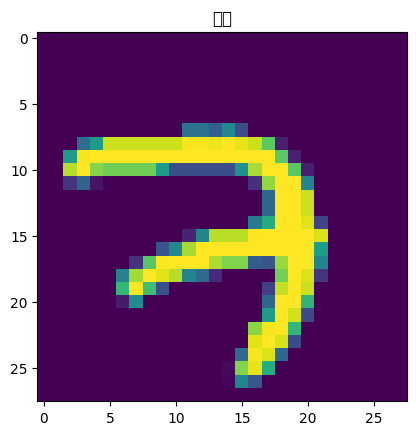

d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 27169 (\N{CJK UNIFIED IDEOGRAPH-6A21}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 31946 (\N{CJK UNIFIED IDEOGRAPH-7CCA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 21518 (\N{CJK UNIFIED IDEOGRAPH-540E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
d:\Anaconda\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 20687 (\N{CJK UNIFIED IDEOGRAPH-50CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


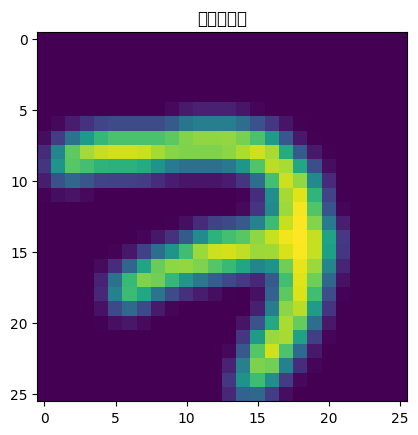

In [107]:
# 一整个 MNIST 手写数字
image = np.array([0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0.3803922 , 0.37647063, 0.3019608 ,0.46274513, 0.2392157 , 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0.3529412 , 0.5411765 , 0.9215687 ,0.9215687 , 0.9215687 , 0.9215687 , 0.9215687 , 0.9215687 ,0.9843138 , 0.9843138 , 0.9725491 , 0.9960785 , 0.9607844 ,0.9215687 , 0.74509805, 0.08235294, 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.54901963,0.9843138 , 0.9960785 , 0.9960785 , 0.9960785 , 0.9960785 ,0.9960785 , 0.9960785 , 0.9960785 , 0.9960785 , 0.9960785 ,0.9960785 , 0.9960785 , 0.9960785 , 0.9960785 , 0.9960785 ,0.7411765 , 0.09019608, 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0.8862746 , 0.9960785 , 0.81568635,0.7803922 , 0.7803922 , 0.7803922 , 0.7803922 , 0.54509807,0.2392157 , 0.2392157 , 0.2392157 , 0.2392157 , 0.2392157 ,0.5019608 , 0.8705883 , 0.9960785 , 0.9960785 , 0.7411765 ,0.08235294, 0., 0., 0., 0.,0., 0., 0., 0., 0.,0.14901961, 0.32156864, 0.0509804 , 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.13333334,0.8352942 , 0.9960785 , 0.9960785 , 0.45098042, 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0.32941177, 0.9960785 ,0.9960785 , 0.9176471 , 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0.32941177, 0.9960785 , 0.9960785 , 0.9176471 ,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0.4156863 , 0.6156863 ,0.9960785 , 0.9960785 , 0.95294124, 0.20000002, 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0.09803922, 0.45882356, 0.8941177 , 0.8941177 ,0.8941177 , 0.9921569 , 0.9960785 , 0.9960785 , 0.9960785 ,0.9960785 , 0.94117653, 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0.26666668, 0.4666667 , 0.86274517,0.9960785 , 0.9960785 , 0.9960785 , 0.9960785 , 0.9960785 ,0.9960785 , 0.9960785 , 0.9960785 , 0.9960785 , 0.5568628 ,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0.14509805, 0.73333335,0.9921569 , 0.9960785 , 0.9960785 , 0.9960785 , 0.8745099 ,0.8078432 , 0.8078432 , 0.29411766, 0.26666668, 0.8431373 ,0.9960785 , 0.9960785 , 0.45882356, 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0.4431373 , 0.8588236 , 0.9960785 , 0.9490197 , 0.89019614,0.45098042, 0.34901962, 0.12156864, 0., 0.,0., 0., 0.7843138 , 0.9960785 , 0.9450981 ,0.16078432, 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0.6627451 , 0.9960785 ,0.6901961 , 0.24313727, 0., 0., 0.,0., 0., 0., 0., 0.18823531,0.9058824 , 0.9960785 , 0.9176471 , 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0.07058824, 0.48627454, 0., 0.,0., 0., 0., 0., 0.,0., 0., 0.32941177, 0.9960785 , 0.9960785 ,0.6509804 , 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0.54509807, 0.9960785 , 0.9333334 , 0.22352943, 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0.8235295 , 0.9803922 , 0.9960785 ,0.65882355, 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0.9490197 , 0.9960785 , 0.93725497, 0.22352943, 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0.34901962, 0.9843138 , 0.9450981 ,0.3372549 , 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.01960784,0.8078432 , 0.96470594, 0.6156863 , 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0.01568628, 0.45882356, 0.27058825,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0., 0.,0., 0., 0., 0.], dtype=np.float32)
image_torch = torch.from_numpy(image).view(1, 1, 28, 28)

# 高斯模糊卷积核
gaussian_kernel = torch.tensor([[1., 2, 1],[2, 4, 2],[1, 2, 1]]) / 16.0

conv = nn.Conv2d(1, 1, 3)
# 手动设置卷积核权重
conv.weight.data[:] = gaussian_kernel

convolved = conv(image_torch)

plt.title('原图')
plt.imshow(image_torch.view(28,28).detach().numpy())
plt.show()

plt.title('模糊后图像')
plt.imshow(convolved.view(26,26).detach().numpy())
plt.show()

In [108]:
im_channels = 3 # 若使用 RGB 图像，输入通道数为 3；黑白图像则为 1
out_channels = 16 # 这是可调超参数
kernel_size = 3 # 这也是可调超参数
batch_size = 4
image_width = 32
image_height = 32

im = torch.randn(batch_size, im_channels, image_width, image_height)

m = nn.Conv2d(im_channels, out_channels, kernel_size)
convolved = m(im) # m 是模块对象，可像函数一样调用

print('输入图像形状', im.shape)
print('卷积后图像形状', convolved.shape)


输入图像形状 torch.Size([4, 3, 32, 32])
卷积后图像形状 torch.Size([4, 16, 30, 30])


In [109]:
def process_corpus(corpus, sentence_length):
    """
    参数：
        corpus (str) -- 连续文本，可以是任意内容，但建议足够长。
        sentence_length (int) -- 输出中每个句子的长度。
            不要求能整除语料词数；若不能整除，末尾会自动填充。
    返回：
        一个包含 4 项的元组：
            - 训练输入：形状为 (batch, sentence)，每个位置是词索引。
            - 训练标签：与训练输入同形状，但每个位置是下一个词的索引。
            - 词到索引字典：每个词对应一个整数索引。
            - 索引到词字典：词到索引字典的反向映射。

    示例：
        process_corpus("Sam likes cats", 2) 输出：
            - [[1, 2], [3, 0]]
            - [[2, 3], [0, 0]]
            - {"": 0, "Sam": 1, "likes": 2, "cats": 3}
            - {0: "", 1: "Sam", 2: "likes", 3: "cats"}
    """
    # 先把语料拆成词列表
    corpus = corpus.split()
    # 思考：这里是否要做去标点/转小写？例如 "You," 和 "you" 是否应视为同一个词？

    # 再按 sentence_length 切分为更短的句子
    x = []
    y = []
    for idx in range(0, len(corpus), sentence_length):
        x.append(corpus[idx: idx + sentence_length])
        # 目标是预测下一个词，因此 y 可看作 x 向后平移一位
        y.append(corpus[idx + 1: idx + sentence_length + 1])
    # 最后一句可能不足长度，需要做填充
    x[-1] += ["" for _ in range(sentence_length - len(x[-1]))]
    y[-1] += ["" for _ in range(sentence_length - len(y[-1]))]

    # 构建词到索引与索引到词的双向字典
    # 思考：用空字符串作为句末/填充标记是否合适？是否也需要在句首填充？
    idx_to_word = {0: ""}
    word_to_idx = {"": 0}
    idx = 1
    for sentence in x:
        for word in sentence:
            if word not in word_to_idx:
                word_to_idx[word] = idx
                idx_to_word[idx] = word
                idx += 1

    x_idx = torch.tensor([[word_to_idx[w] for w in s] for s in x]).long()
    y_idx = torch.tensor([[word_to_idx[w] for w in s] for s in y]).long()

    return x_idx, y_idx, word_to_idx, idx_to_word


In [110]:
# 可自行调整这些参数
embedding_size = 10
sentence_length = 5
hidden_size = 5
n_epochs = 1000

# 数据集
corpus = "Hey, you. You’re finally awake. " \
    "You were trying to cross the border, right? " \
    "Walked right into that Imperial ambush, " \
    "same as us, and that thief over there. " \
    "Skyrim was fine until you came along. " \
    "Empire was nice and lazy. " \
    "If they hadn’t been looking for you, " \
    "I could’ve stolen that horse and been half way to Hammerfell. " \
    "You there. You and me — we should be here. " \
    "It’s these Stormcloaks the Empire wants. "

x, y, word_to_idx, idx_to_word = process_corpus(corpus, sentence_length)

model_rnn = nn.Sequential(
    nn.Embedding(len(idx_to_word), embedding_size),
    nn.RNN(embedding_size, hidden_size, batch_first=True),
)
# 线性层单独定义，因为我们只取 RNN 的第一个返回值作为输入
linear = nn.Linear(hidden_size, len(idx_to_word))
print(model_rnn)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(list(model_rnn.parameters()) + list(linear.parameters()))

for i in range(n_epochs):
    x_mid, _ = model_rnn(x)
    y_hat = linear(x_mid).transpose(1, 2)  # This makes shape correct for the Loss
    loss = criterion(y_hat, y)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if i % (n_epochs // 10) == 0:
        print('{},\t{:.2f}'.format(i, loss.item()))


Sequential(
  (0): Embedding(61, 10)
  (1): RNN(10, 5, batch_first=True)
)
0,	4.21
100,	3.79
200,	3.32
300,	2.87
400,	2.51
500,	2.23
600,	2.01
700,	1.83
800,	1.69
900,	1.57


In [111]:
# 看看第一个句子的预测结果
with torch.no_grad():
    y_hat = linear(model_rnn(x)[0])
    y_hat = torch.argmax(y_hat, dim=2)
    sentences_hat = [[idx_to_word[int(w)] for w in s] for s in y_hat]
    sentences_true = [[idx_to_word[int(w)] for w in s] for s in y]

    sentence_idx = 0
    print(f"真实：{sentences_true[sentence_idx]}")
    print(f"预测：{sentences_hat[sentence_idx]}")

# 用一个随机起始词生成自定义句子。
with torch.no_grad():
    word = "horse"
    sentence = f"{word}"
    for _ in range(15):
        word_idx = torch.tensor([word_to_idx[word]]).reshape(1, 1)
        y_hat, _ = model_rnn(word_idx)
        y_hat = linear(y_hat)
        y_hat = torch.argmax(y_hat, dim=2)
        word = idx_to_word[y_hat.reshape(1).item()]
        sentence += f" {word}"
    print(sentence)
    # 注意末尾会出现重复，这个问题有对应改进方法。


真实：['you.', 'You’re', 'finally', 'awake.', 'You']
预测：['you.', 'into', 'came', 'awake.', 'You']
horse and that thief came into that thief came into that thief came into that thief
